# Python for AI — Class 16
### Matplotlib and Seaborn: draw charts of your data

In Pandas we made tables. But a table with 100 rows is hard to read.
A **chart** shows the pattern in one look.

Today we learn to draw the 4 basic charts, make them look good, and use charts to answer a real question:
**"Is this column related to that column?"**

## How we will learn today

Every topic has the same 4 steps:

| Step | What happens |
|------|--------------|
| **CONCEPT** | The teacher explains the idea. Short points. |
| **EXAMPLE** | The teacher types the code. **You type it too** and run it. |
| **QUICK CHECK** | You solve a small task alone. |
| **SOLUTION** | We check the answer together. The solutions are in a separate file. |

**Tip:** Run a cell with `Shift + Enter`.

# Hour 1: Matplotlib basics

## Meet the libraries: Matplotlib and Seaborn

### Matplotlib

| Question | Answer |
|----------|--------|
| **What does the name mean?** | **Mat** (from MATLAB, a maths program) + **plot** (chart) + **lib** (library) |
| **Who made it?** | **John D. Hunter**, an American scientist, in **2003** |
| **Why did he make it?** | He studied the brains of people with epilepsy (a brain illness). He had a lot of brain data and needed charts. Good chart tools were in MATLAB, but MATLAB is expensive. So he made a **free** chart library for Python. |
| **Who uses it?** | scientists, data analysts, AI and ML engineers, students. Even NASA used it in its Phoenix mission to Mars |
| **Who looks after it now?** | John Hunter died in 2012. Now many volunteers around the world keep it updated. It is free and open source |
| **How do we import it?** | `import matplotlib.pyplot as plt` |

`pyplot` is the part of Matplotlib that we use to draw charts. `plt` is its short name. Everyone uses `plt`.

#### Common Matplotlib methods

| Method | What it does | Today? |
|--------|--------------|--------|
| `plt.plot(x, y)` | line chart | ✅ |
| `plt.bar(x, y)` | bar chart | ✅ |
| `plt.hist(values)` | histogram | ✅ |
| `plt.scatter(x, y)` | scatter chart (dots) | ✅ |
| `plt.pie(values)` | pie chart | |
| `plt.title("...")` | add a title on top | ✅ |
| `plt.xlabel("...")`, `plt.ylabel("...")` | add a name to the x-axis and y-axis | ✅ |
| `plt.legend()` | show which colour is which line | ✅ |
| `plt.figure(figsize=(8, 5))` | set the size of the chart | ✅ |
| `plt.subplots(1, 2)` | many charts side by side | |
| `plt.savefig("chart.png")` | save the chart as a picture | ✅ |
| `plt.show()` | show the chart | ✅ |

### Seaborn

| Question | Answer |
|----------|--------|
| **What does the name mean?** | It comes from **Samuel Norman Seaborn**, a character in an American TV drama, *The West Wing*. His initials are **S. N. S.** That is why we write `sns`! |
| **Who made it?** | **Michael Waskom**, a student at Stanford University (USA), in **2012** |
| **Why did he make it?** | He was also studying the brain. Matplotlib can draw anything, but it needs many lines of code. He wanted **beautiful charts** from a **Pandas table** with **one line**, especially charts for statistics (averages, spread, relations). |
| **Who uses it?** | data analysts and data scientists, mostly for **EDA**: exploring data before building a model |
| **How is it related to Matplotlib?** | Seaborn is built **on top of** Matplotlib. Seaborn draws the chart, but Matplotlib is still working inside. So `plt.title()` and `plt.show()` still work with Seaborn charts |
| **How do we import it?** | `import seaborn as sns` |

#### Common Seaborn methods

| Method | What it does | Today? |
|--------|--------------|--------|
| `sns.set_theme(style="whitegrid")` | a clean style for all charts | ✅ |
| `sns.histplot(data=df, x="col")` | histogram | ✅ |
| `sns.countplot(data=df, x="col")` | counts each value and draws bars | ✅ |
| `sns.barplot(data=df, x="col", y="col")` | bar chart of the **average** | ✅ |
| `sns.boxplot(data=df, x="col", y="col")` | box plot: spread and outliers | ✅ |
| `sns.scatterplot(data=df, x="col", y="col")` | scatter chart (dots) | ✅ |
| `sns.regplot(data=df, x="col", y="col")` | scatter chart + a straight line | ✅ |
| `sns.heatmap(table)` | coloured table, for correlation | ✅ |
| `sns.lineplot(data=df, x="col", y="col")` | line chart | |
| `sns.pairplot(df)` | scatter charts for **every pair** of columns | |
| `sns.load_dataset("tips")` | load a free practice dataset (needs internet) | |

### Which one should I use?

| Use **Matplotlib** when... | Use **Seaborn** when... |
|----------------------------|-------------------------|
| you want full control of every small detail | you have a Pandas table and want a good chart fast |
| you draw simple charts from lists or arrays | you want statistics charts: box plot, heatmap, regplot |

In real work, we use **both together**: Seaborn to draw, Matplotlib to add the title, labels and size, and to save.

## Get the data

The cell below makes a table of **100 students** and a table of **monthly temperatures**.

Columns in `df`:

| Column | Meaning |
|--------|---------|
| `city` | Lahore, Karachi or Islamabad |
| `study_hours` | hours of study each day |
| `phone_hours` | hours on the phone each day |
| `height_cm` | height in cm |
| `maths`, `english`, `science` | marks out of 100 |

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Run this cell once. It makes a file students_100.csv with 100 students.
# You don't need to understand every line. It only makes the data.
rng = np.random.default_rng(7)
n = 100
study = rng.normal(3, 1.2, n).clip(0, 8).round(1)
phone = rng.normal(4, 1.5, n).clip(0, 10).round(1)
maths = (45 + study * 9 - phone * 4 + rng.normal(0, 7, n)).clip(0, 100).round()
pd.DataFrame({
    "student_id": range(1, n + 1),
    "city": rng.choice(["Lahore", "Karachi", "Islamabad"], n),
    "study_hours": study,                                   # hours of study each day
    "phone_hours": phone,                                   # hours on the phone each day
    "height_cm": rng.normal(165, 8, n).round(),
    "maths": maths,
    "english": (45 + study * 6 + rng.normal(0, 9, n)).clip(0, 100).round(),
    "science": (0.6 * maths + 28 + rng.normal(0, 6, n)).clip(0, 100).round(),
}).to_csv("students_100.csv", index=False)

df = pd.read_csv("students_100.csv")

# Average temperature (°C) in each month
temps = pd.DataFrame({
    "month":     ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
    "lahore":    [13, 16, 22, 28, 32, 34, 31, 30, 29, 25, 19, 14],
    "karachi":   [19, 21, 25, 28, 31, 31, 30, 29, 29, 28, 25, 21],
    "islamabad": [10, 13, 17, 23, 28, 31, 29, 28, 26, 21, 15, 11],
})

In [6]:
print(df.shape)
df.head()

(100, 8)


,student_id,city,study_hours,phone_hours,height_cm,maths,english,science
0,1,Lahore,3.0,3.5,177.0,49.0,61.0,54.0
1,2,Islamabad,3.4,2.7,173.0,71.0,59.0,71.0
2,3,Lahore,2.7,4.2,157.0,56.0,66.0,54.0
3,4,Karachi,1.9,7.4,158.0,39.0,55.0,53.0
4,5,Lahore,2.5,2.8,161.0,69.0,65.0,70.0


In [7]:
temps

,month,lahore,karachi,islamabad
0,Jan,13,19,10
1,Feb,16,21,13
2,Mar,22,25,17
3,Apr,28,28,23
4,May,32,31,28
5,Jun,34,31,31
6,Jul,31,30,29
7,Aug,30,29,28
8,Sep,29,29,26
9,Oct,25,28,21


## CONCEPT: What is Matplotlib?

- **Matplotlib** is the main library for charts in Python.
- We write `import matplotlib.pyplot as plt`. Everyone uses the short name `plt`.
- Every chart has 3 steps: **draw** it → add a **title and labels** → **show** it with `plt.show()`.
- A chart with no title and no labels is not finished. Nobody knows what it shows.

There are 4 basic charts. Learn when to use each one:

| Chart | Use it to... | Example |
|-------|--------------|---------|
| **Line** | see change over time | temperature each month |
| **Bar** | compare groups | average marks of each city |
| **Histogram** | see how values are spread | how many students got 40s, 50s, 60s... |
| **Scatter** | see if two numbers are related | study hours vs maths marks |

## CONCEPT: Line chart

- `plt.plot(x, y)` draws a line. `x` goes left to right. `y` goes up and down.
- `marker="o"` puts a dot on each point.
- For many lines: give each line a `label=`, then call `plt.legend()`. The legend shows which line is which.

### EXAMPLE: Lahore temperature in a year

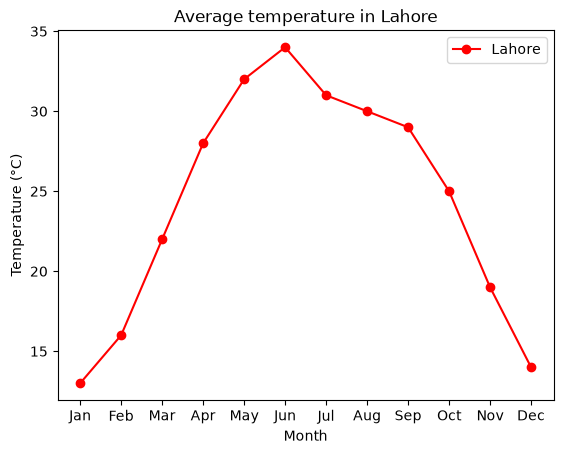

In [8]:
plt.plot(temps["month"], temps["lahore"], marker="o", label="Lahore", color = "red")

plt.title("Average temperature in Lahore")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()

### ✏️ QUICK CHECK 1: Line chart

Draw **Lahore and Karachi** on the same chart. Give each line a `label`, and add `plt.legend()`. Add a title and labels.

Which city has a bigger change between winter and summer?

Write your code in the cell below.

Text(0, 0.5, 'Temperature')

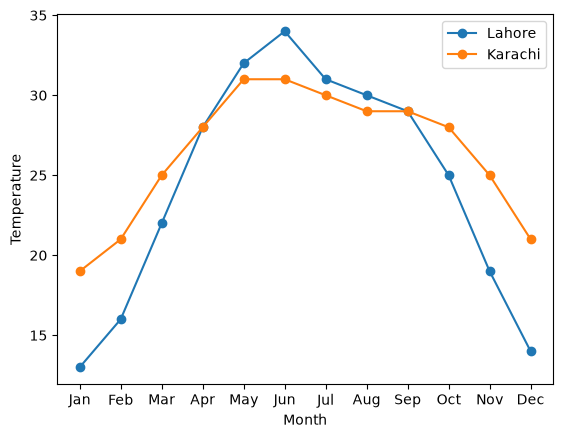

In [9]:
# Write your code here
import matplotlib.pyplot as plt
plt.plot(temps["month"], temps["lahore"], marker = "o", label = "Lahore")
plt.plot(temps["month"], temps["karachi"], marker = "o", label = "Karachi")
plt.legend()
plt.xlabel("Month")
plt.ylabel("Temperature")

## CONCEPT: Bar chart

- `plt.bar(names, values)` draws one bar for each name.
- Use it to **compare groups**: cities, products, classes.
- First make the numbers with Pandas (like `groupby`). Then draw them.
- `avg.index` = the names (cities). `avg.values` = the numbers.

### EXAMPLE: Average Maths of each city

city
Islamabad    53.484848
Karachi      54.517241
Lahore       53.447368
Name: maths, dtype: float64


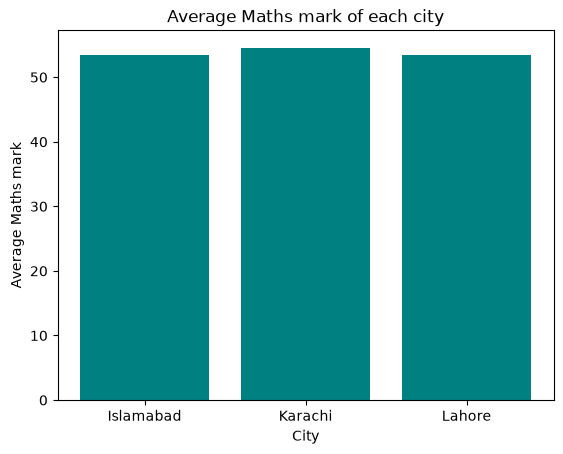

In [10]:
avg = df.groupby("city")["maths"].mean()
print(avg)

plt.bar(avg.index, avg.values, color="teal")
plt.title("Average Maths mark of each city")
plt.xlabel("City")
plt.ylabel("Average Maths mark")
plt.show()

### ✏️ QUICK CHECK 2: Bar chart

Draw a bar chart of **how many students are in each city**. (Hint: `df["city"].value_counts()`.) Add a title and labels.

Write your code in the cell below.

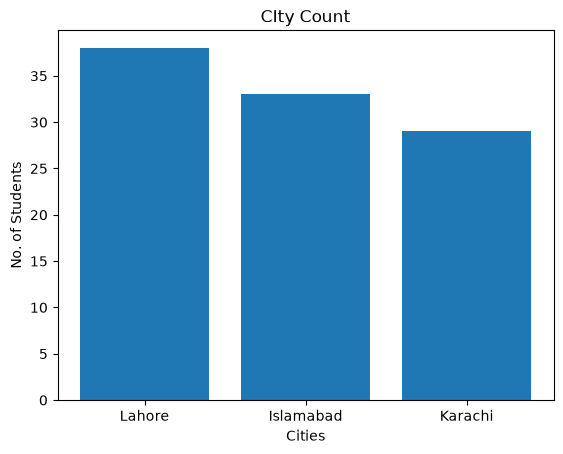

In [ ]:
# Write your code here
avg = df["city"].value_counts()
print(avg)
plt.bar(avg.index, avg.values)
plt.xlabel("Cities")
plt.ylabel("No. of Students")
plt.title("CIty Count")
plt.show()



## CONCEPT: Histogram

- A histogram shows **how the values are spread**.
- It puts the values into groups called **bins** (like 40–50, 50–60, 60–70) and draws a bar for each bin.
- The height of a bar = **how many** values are in that bin.
- `plt.hist(column, bins=10)` → 10 bins.
- We use it to see: where most values are, and if there are strange values far away.

### EXAMPLE: How are the Maths marks spread?

(array([ 3.,  4.,  6.,  8., 13., 15., 18., 13.,  9., 11.]),
 array([22. , 27.4, 32.8, 38.2, 43.6, 49. , 54.4, 59.8, 65.2, 70.6, 76. ]),
 <BarContainer object of 10 artists>)

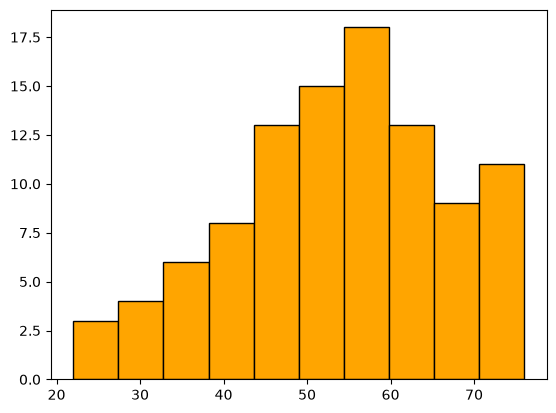

In [ ]:
plt.hist(df["maths"], bins = 10, color = "orange", edgecolor = "Black")
plt.title("Maths marks of 100 students")
plt.xlabel("Maths mark")
plt.ylabel("Number of students")
plt.show()

Most students got between 40 and 70. Very few got below 30. Nobody got above 80.

### ✏️ QUICK CHECK 3: Histogram

Draw a histogram of `study_hours` with `bins=12`. Add a title and labels.

Most students study about how many hours a day?

Write your code in the cell below.

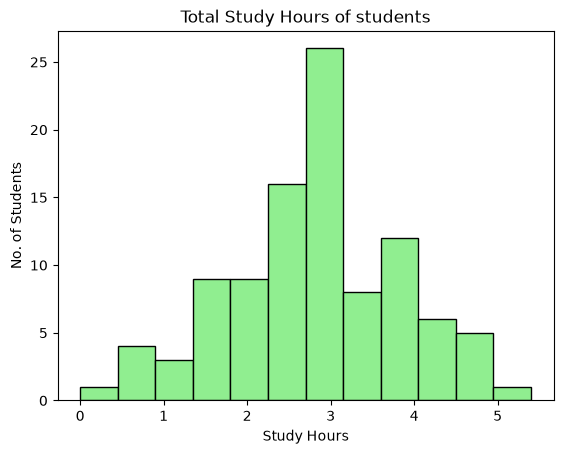

In [37]:
# Write your code here
plt.hist(df["study_hours"], bins = 12, color = "lightgreen", edgecolor = "black")
plt.title("Total Study Hours of students")
plt.xlabel("Study Hours")
plt.ylabel("No. of Students")
plt.show()


## CONCEPT: Scatter chart

- `plt.scatter(x, y)` draws **one dot for each row**.
- Use it to see if **two numbers are related**.
- If the dots go **up** from left to right: when x grows, y grows.
- If the dots go **down**: when x grows, y gets smaller.
- If the dots are everywhere like a cloud: no relation.

### EXAMPLE: Study hours vs Maths marks

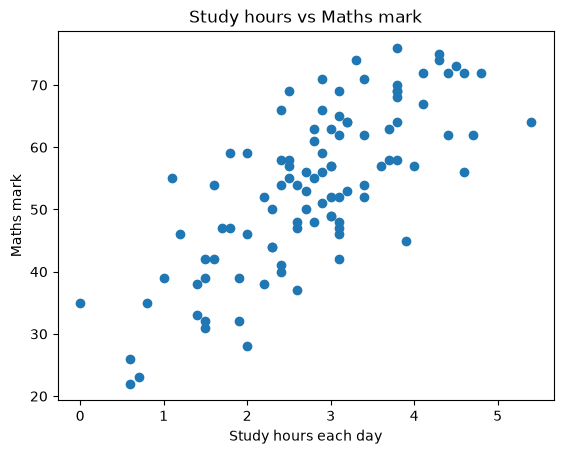

In [38]:
plt.scatter(df["study_hours"], df["maths"])
plt.title("Study hours vs Maths mark")
plt.xlabel("Study hours each day")
plt.ylabel("Maths mark")
plt.show()

The dots go **up**. Students who study more usually get higher Maths marks.

### ✏️ QUICK CHECK 4: Scatter chart

Draw a scatter chart of `phone_hours` (x) vs `maths` (y). Add a title and labels.

Do the dots go up, go down, or look like a cloud?

Write your code in the cell below.

Text(0, 0.5, 'Maths mark')

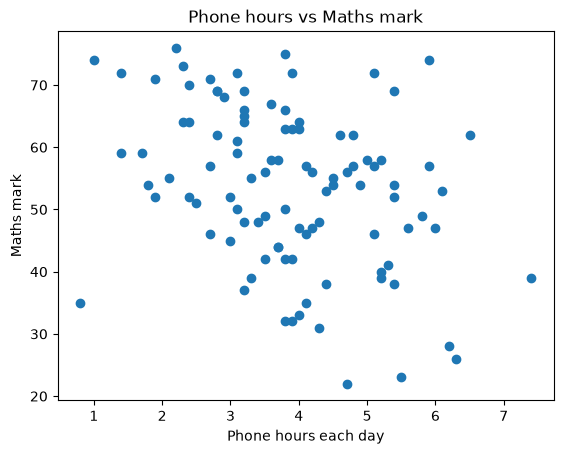

In [41]:
# Write your code here
plt.scatter(df["phone_hours"], df["maths"])
plt.title("Phone hours vs Maths mark")
plt.xlabel("Phone hours each day")
plt.ylabel("Maths mark")


# Hour 2: Seaborn

## CONCEPT: What is Seaborn?

- **Seaborn** is built on top of Matplotlib. It makes good-looking charts with **less code**.
- We write `import seaborn as sns`.
- You give it the **DataFrame** and the **column names**: `sns.histplot(data=df, x="maths")`.
- It still uses Matplotlib inside, so `plt.title(...)` and `plt.show()` still work.
- `sns.set_theme(style="whitegrid")` gives every chart a clean style with grid lines.

### EXAMPLE: The same charts, with Seaborn

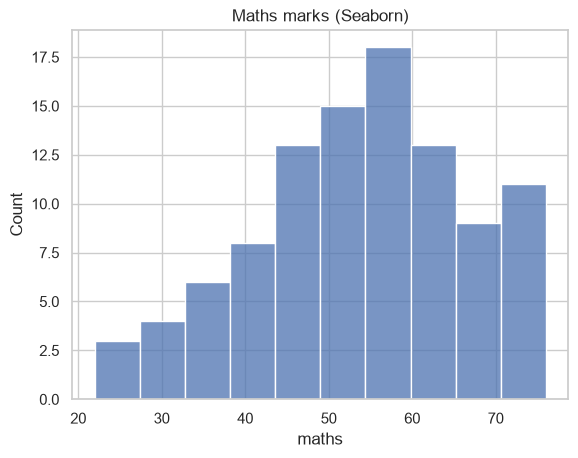

In [45]:
sns.set_theme(style="whitegrid")

sns.histplot(data=df, x="maths", bins=10)
plt.title("Maths marks (Seaborn)")
plt.show()

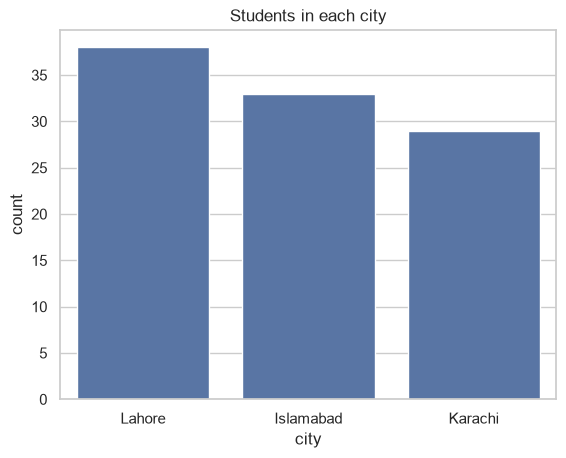

In [46]:
sns.countplot(data=df, x="city")       # counts the rows for each city. No value_counts needed
plt.title("Students in each city")
plt.show()

## CONCEPT: Box plot

- A box plot shows the spread of the values in one small picture.
- It is very good for **comparing groups**, and for finding **outliers** (strange values far from the rest).

```
      o           ← outlier: a value far away from the others
      |
   ┌──┴──┐        ← top of box    = 75% of students are below this
   │     │
   ├─────┤        ← middle line   = the median (middle value)
   │     │
   └──┬──┘        ← bottom of box = 25% of students are below this
      |           ← the lines (whiskers) show the normal range
```

- Write: `sns.boxplot(data=df, x="city", y="maths")` → one box for each city.

### EXAMPLE: Maths marks in each city

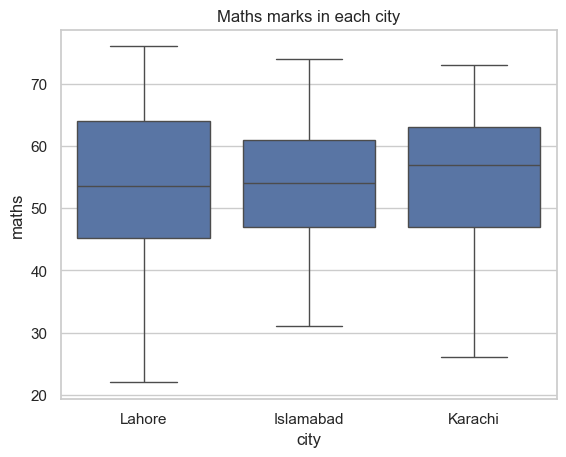

In [20]:
sns.boxplot(data=df, x="city", y="maths")
plt.title("Maths marks in each city")
plt.show()

### ✏️ QUICK CHECK 5: Box plot

Draw a box plot of `english` marks for each `city`. Add a title.

Which city has the highest middle line (median)? Do you see any outliers?

Write your code in the cell below.

<Axes: xlabel='city', ylabel='english'>

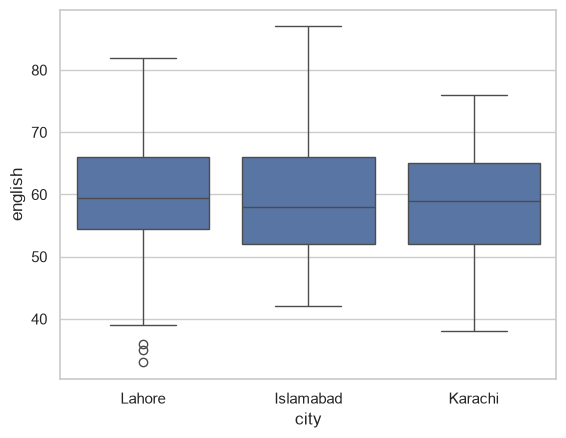

In [48]:
# Write your code here
sns.boxplot(data = df, y = "english", x = "city")

## CONCEPT: Correlation and heatmap

- **Correlation** is one number that tells how strongly two columns are related.
- It is always between **-1** and **+1**:

| Value | Meaning | Example |
|-------|---------|---------|
| near **+1** | when one goes up, the other goes up | study hours ↑, marks ↑ |
| near **0** | no relation | height and marks |
| near **-1** | when one goes up, the other goes down | phone hours ↑, marks ↓ |

- `df.corr(numeric_only=True)` gives the correlation of **every pair** of number columns.
- A **heatmap** colours this table. Strong colour = strong relation. `annot=True` writes the numbers inside.

### EXAMPLE: Correlation of all number columns

In [58]:
corr = df.drop(columns="student_id").corr(numeric_only=True).round(2)
corr

,study_hours,phone_hours,height_cm,maths,english,science
study_hours,1.00,0.02,0.00,0.75,0.64,0.66
phone_hours,0.02,1.00,-0.13,-0.34,0.05,-0.16
height_cm,0.00,-0.13,1.00,-0.05,-0.04,-0.10
maths,0.75,-0.34,-0.05,1.00,0.47,0.81
english,0.64,0.05,-0.04,0.47,1.00,0.46
science,0.66,-0.16,-0.10,0.81,0.46,1.00


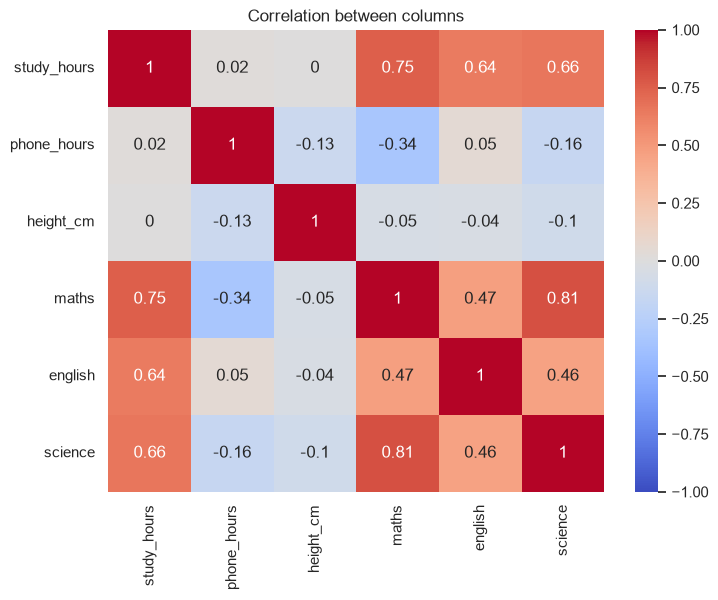

In [64]:
plt.figure(figsize=(8, 6))          # make the chart bigger: width 8, height 6
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation between columns")
plt.show()

How to read it: find the `study_hours` row and the `maths` column. The number is high and the colour is dark red. They are strongly related.
`height_cm` is near 0 with everything. Height has no relation with marks.

### ✏️ QUICK CHECK 6: Heatmap

Make a heatmap for **only** the 3 mark columns: `maths`, `english`, `science`. Use `annot=True`.

Which two subjects are most related?

Write your code in the cell below.

In [ ]:
# Write your code here

## CONCEPT: Make charts look good and save them

- `hue="city"` gives each city its own colour. A legend is added for you.
- `plt.figure(figsize=(8, 5))` sets the size of the chart.
- `plt.savefig("name.png", dpi=150, bbox_inches="tight")` saves the chart as a picture file. You can put it in a report or on LinkedIn.
- **Important:** call `plt.savefig(...)` **before** `plt.show()`. After `show()`, the chart is empty.

### EXAMPLE: A coloured scatter chart, saved as a picture

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="study_hours", y="maths", hue="city")
plt.title("Study hours vs Maths, by city")
plt.xlabel("Study hours each day")
plt.ylabel("Maths mark")
plt.savefig("study_vs_maths.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: study_vs_maths.png")

### ✏️ QUICK CHECK 7: Bar chart with Seaborn + save

Draw `sns.barplot(data=df, x="city", y="science", errorbar=None)`. It shows the **average** Science mark of each city. (`errorbar=None` removes the small black lines.)

Add a title, and save it as `science_by_city.png`.

Write your code in the cell below.

<Axes: xlabel='city', ylabel='science'>

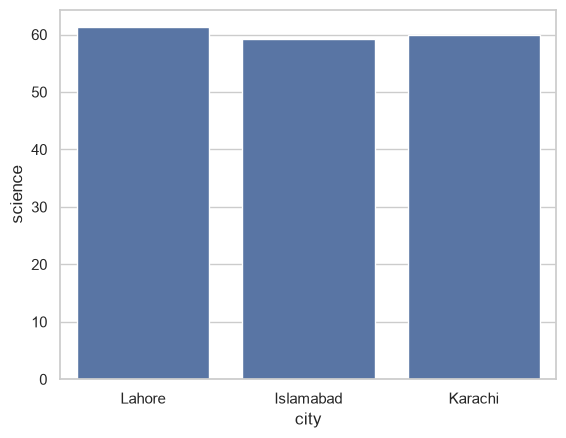

In [53]:
# Write your code here
sns.barplot(data=df, x="city", y="science", errorbar = None)

# Hour 3: Practice: Is X related to Y?

## CONCEPT: How to check if two columns are related

Use 3 steps:

1. **Look:** draw a scatter chart.
2. **Measure:** find the correlation number: `df["a"].corr(df["b"])`.
3. **Say it in words:** "When study hours go up, Maths marks also go up. The relation is strong (0.8)."

How strong is the number? (Look at the size, and ignore the minus sign.)

| Size of the number | Relation |
|--------------------|----------|
| 0.7 or more | strong |
| 0.3 to 0.7 | medium |
| less than 0.3 | weak or none |

**Be careful:** related does **not** mean one causes the other. On rainy days, people carry more umbrellas. But umbrellas do not cause the rain.

### EXAMPLE: Is study time related to Maths marks?

**The story**

A school principal in Lahore asks you a question:

> "Parents always tell children: *study more, get better marks*. Is this really true in our school? Show me with data."

We have data for 100 students. For each student we know:
- `study_hours`: how many hours they study each day
- `maths`: their Maths mark out of 100

**First, think with a small example**

Look at 5 students:

| Student | Study hours | Maths mark |
|---------|-------------|------------|
| Bilal | 1 | 35 |
| Sara | 2 | 48 |
| Ali | 3 | 55 |
| Ayesha | 4 | 66 |
| Hassan | 5 | 72 |

Can you see the pattern? When study hours go **up**, the marks also go **up**. That is a relation.

With 5 students, our eyes can see it. With **100 students**, we can't read the table. So we use a chart and one number.

**What the code does**

| Step | Code | In simple words |
|------|------|-----------------|
| 1. Look | `sns.regplot(...)` | Draw one dot for each student. Then draw a straight line that goes through the middle of the dots |
| 2. Measure | `df["study_hours"].corr(df["maths"])` | Give one number from -1 to +1 that says how strong the relation is |
| 3. Say it | `print(...)` | Write the answer in a sentence the principal can understand |

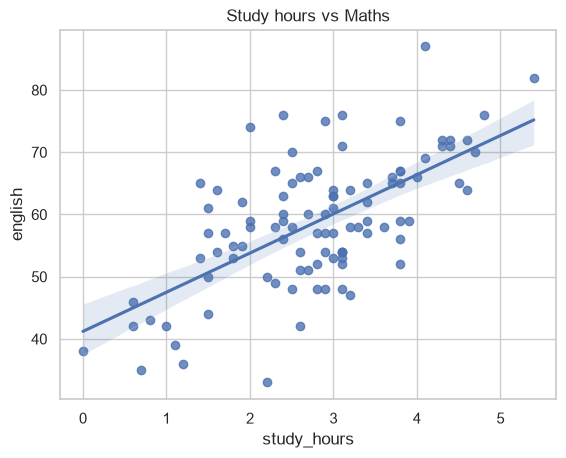

Correlation: 0.64
More study hours -> higher Maths marks. The relation is strong.


In [ ]:
# Step 1: look. regplot = scatter + a straight line that follows the dots
sns.regplot(data=df, x="study_hours", y="maths")
plt.title("Study hours vs Maths")
plt.show()

# Step 2: measure
r = df["study_hours"].corr(df["maths"])
print("Correlation:", round(r, 2))

# Step 3: say it in words
print("More study hours -> higher Maths marks. The relation is strong.")

**How to read the result**

**The chart:**
- Each **dot** is **one student**.
  - Left = studies less. Right = studies more.
  - Low = low marks. High = high marks.
- The **line** goes **up** from left to right. So more study hours usually means higher marks.
- The dots are **close to the line**. So the pattern is clear, not random.
- Some dots are far from the line. For example, a student who studies a lot but got a low mark. That is normal. Marks also depend on other things: sleep, phone time, a good teacher.

**The number:** the correlation is about **0.75**.
- It is **positive** (+), so both go up together.
- It is **0.7 or more**, so the relation is **strong** (see the table above).

**Our answer to the principal:**

> "Yes. In our school, students who study more usually get higher Maths marks. The relation is strong (0.75). But it is not a promise for every student. Some students study a lot and still get low marks, so other things matter too."

**Remember:** this shows that study time and marks are **related**. To prove that studying **causes** better marks, we would need a proper experiment. But here, it makes sense, and it matches what parents say.

## What is the line? And what is the slope?

**The line** is called the **line of best fit**.

- The dots are spread out. No straight line can touch all of them.
- So the computer tries many straight lines. It keeps the one that is **closest to all the dots together**.
- This line shows the **main direction** of the data, and ignores the small ups and downs.

**Every straight line has 2 numbers:**

```
maths  =  slope × study_hours  +  start
```

| Number | Meaning | In our data |
|--------|---------|-------------|
| **slope** | how much `maths` goes up when `study_hours` goes up by **1** | about **9.2** |
| **start** (intercept) | the value of `maths` when `study_hours` is **0**. The point where the line starts on the left | about **28** |

**What is the slope? Think of a road on a hill:**

```
 steep road              gentle road            flat road            road going down
      /                       _/                 ______                \
     /                     _/                                            \
    /                   _/                                                 \
 big slope             small slope            slope = 0             negative slope
```

- **Big slope** (steep): a small change in `x` gives a big change in `y`.
- **Small slope** (gentle): `y` changes only a little.
- **Slope = 0** (flat): `x` does not change `y`. **No relation.**
- **Negative slope** (going down): when `x` goes up, `y` goes down. Like phone hours and marks.

**Our slope is 9.2. That means:** each extra hour of study gives about **9 more marks**, on average.

Look back at the 5 students in the small table: from 1 hour to 2 hours, the marks went from 35 to 48. From 2 to 3 hours, 48 to 55. From 3 to 4 hours, +11. From 4 to 5 hours, +6. On average, each extra hour gave about **+9 marks**. That is the slope!

**Why is this useful? We can predict.**
A new student studies 3 hours a day. What mark will they probably get?

```
maths = 9.2 × 3 + 28 = 55.6  →  about 56 marks
```

This is a **guess**, not a promise. Real students are above or below the line.

**Good to know:** finding this line is called **linear regression**. It is the **first Machine Learning model** you will learn in Month 2. You have already seen it today!

Let's find the slope and start with code. `np.polyfit(x, y, 1)` finds the best straight line. The `1` means "a straight line".

Slope: 9.2
Start: 28.1
A student who studies 3 hours will probably get about 56 marks


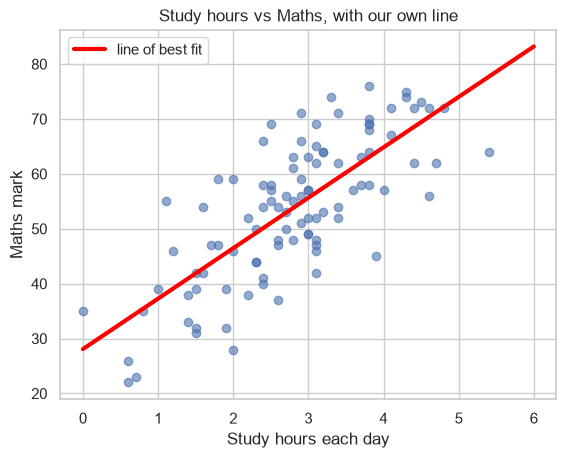

In [52]:
# Find the line of best fit
slope, start = np.polyfit(df["study_hours"], df["maths"], 1)
print("Slope:", round(slope, 1))     # extra marks for each extra hour
print("Start:", round(start, 1))     # marks at 0 hours

# Predict: a student who studies 3 hours a day
hours = 3
guess = slope * hours + start
print("A student who studies", hours, "hours will probably get about", round(guess), "marks")

# Draw the dots and OUR line. It is the same line regplot drew
plt.scatter(df["study_hours"], df["maths"], alpha=0.6)
x_line = np.array([0, 6])
plt.plot(x_line, slope * x_line + start, color="red", linewidth=3, label="line of best fit")
plt.title("Study hours vs Maths, with our own line")
plt.xlabel("Study hours each day")
plt.ylabel("Maths mark")
plt.legend()
plt.show()

### ✏️ QUICK CHECK 8: Phone hours and Maths

Is `phone_hours` related to `maths`? Use the 3 steps: draw a `regplot`, print the correlation, and write your answer in words.

Write your code in the cell below.

In [ ]:
# Write your code here

### ✏️ QUICK CHECK 9: Practice (Harder)

1) Is `height_cm` related to `maths`? Use the 3 steps.
2) Print the correlation of **every** column with `maths`, sorted from low to high. (Hint: `df.corr(numeric_only=True)["maths"].sort_values()`.)
3) Which column is most related to `maths`? Which column has no relation?

Write your code in the cell below.

In [ ]:
# Write your code here

# Home Practice: Interview-Style Questions

1. Which chart would you use to show sales for each month? Which chart to compare 5 products? Why?
2. What does a histogram show? What is a bin?
3. In a box plot, what does the middle line show? What is an outlier?
4. What does a correlation of 0.9 mean? And -0.8? And 0.05?
5. "Ice cream sales and drowning cases are related. So ice cream causes drowning." Is this right? Explain.
6. What is the difference between Matplotlib and Seaborn?

**Extra:** Use the `temps` table. Draw all 3 cities on one line chart with a legend, and save it as `temperatures.png`.

# Key Takeaways

- **Line** = change over time. **Bar** = compare groups. **Histogram** = spread of values. **Scatter** = relation between two numbers.
- Every chart needs a **title** and **labels**.
- Seaborn: give it `data=df` and column names. Use `hue=` for colours by group.
- **Box plot** shows the median, the spread and outliers.
- **Correlation** is between -1 and +1. Check it with a scatter chart and `.corr()`.
- Related does **not** mean "one causes the other".
- `plt.savefig(...)` comes **before** `plt.show()`.

**Next class:** EDA Project: explore a real dataset from start to end. This is your Month 1 portfolio project.